# Frozen fraction f_N vs N — quick look (scratch / exploratory)

Reads the most recent `frozen_fraction_production_*` run under
`numerics/data/raw/` and plots f_N vs N a few different ways, plus the
per-L sample spread. Throwaway view for getting a feel for the data —
not cited in RESEARCH_LOG.md. The actual H1a/H1b/H1c fitting and model
comparison belongs in `notebooks/analysis/`, not here.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RAW_DIR = Path('../../data/raw')
run_dirs = sorted(RAW_DIR.glob('frozen_fraction_production_*'))
run_dir = run_dirs[-1]
print('Using run:', run_dir)

with open(run_dir / 'summary.json') as f:
    summary = json.load(f)
with open(run_dir / 'parameters.json') as f:
    parameters = json.load(f)

summary = sorted(summary, key=lambda row: row['L'])
for row in summary:
    print(f"L={row['L']:5d}  f_N={row['frozen_fraction_mean']:.4f} "
          f"+- {row['frozen_fraction_se']:.4f}  "
          f"(n={row['n_samples']}, discarded={row['n_discarded']})")

Using run: ../../data/raw/frozen_fraction_production_20260912T074229Z
L=  100  f_N=0.3490 +- 0.0035  (n=1420, discarded=0)
L=  200  f_N=0.3523 +- 0.0035  (n=760, discarded=0)
L=  400  f_N=0.3567 +- 0.0034  (n=400, discarded=0)
L=  800  f_N=0.3640 +- 0.0036  (n=160, discarded=0)
L= 1600  f_N=0.3638 +- 0.0034  (n=100, discarded=0)
L= 3200  f_N=0.3603 +- 0.0032  (n=40, discarded=0)
L= 6400  f_N=0.3605 +- 0.0036  (n=20, discarded=0)
L=12800  f_N=0.3621 +- 0.0033  (n=20, discarded=0)
L=25600  f_N=0.3615 +- 0.0016  (n=20, discarded=0)
L=51200  f_N=0.3606 +- 0.0013  (n=20, discarded=0)
L=102400  f_N=0.3580 +- 0.0010  (n=20, discarded=0)


In [2]:
N = np.array([row['L'] for row in summary])
f = np.array([row['frozen_fraction_mean'] for row in summary])
se = np.array([row['frozen_fraction_se'] for row in summary])

## Pure f_N vs L (before any scaling transform)

Plain linear-linear plot of the raw values, before looking at any
of 1/N, ln(N), or log-x transforms below.

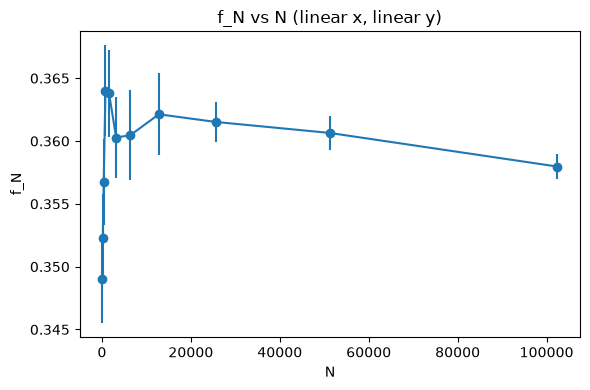

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(N, f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N (linear x, linear y)')
fig.tight_layout()
plt.show()

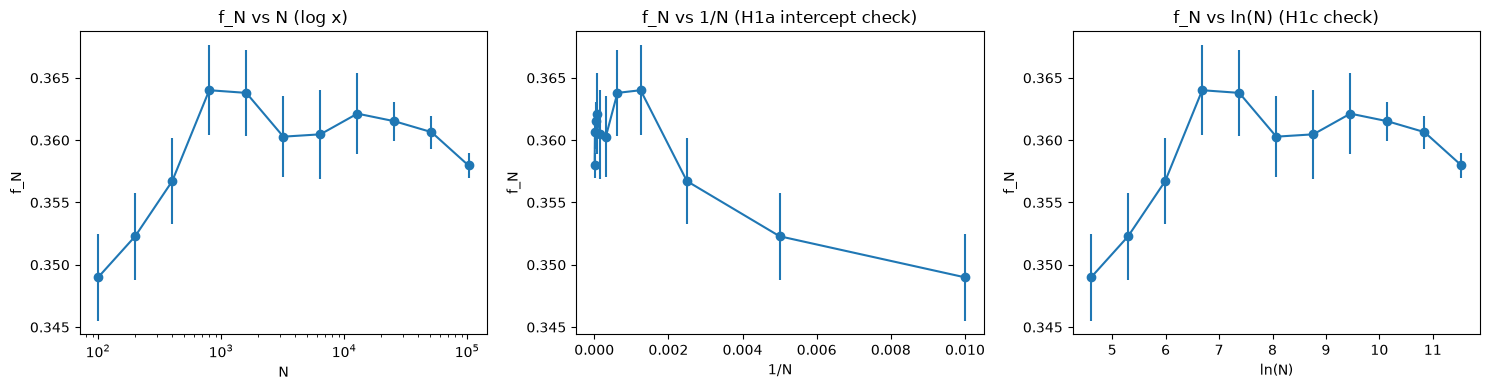

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.errorbar(N, f, yerr=se, marker='o', linestyle='-')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N (log x)')

ax = axes[1]
ax.errorbar(1.0 / N, f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('1/N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs 1/N (H1a intercept check)')

ax = axes[2]
ax.errorbar(np.log(N), f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('ln(N)')
ax.set_ylabel('f_N')
ax.set_title('f_N vs ln(N) (H1c check)')

fig.tight_layout()
plt.show()

## Per-L sample spread

Raw per-realization frozen fractions, to see how variance shrinks with N
(this is what drove the sample-count estimates during cost planning).

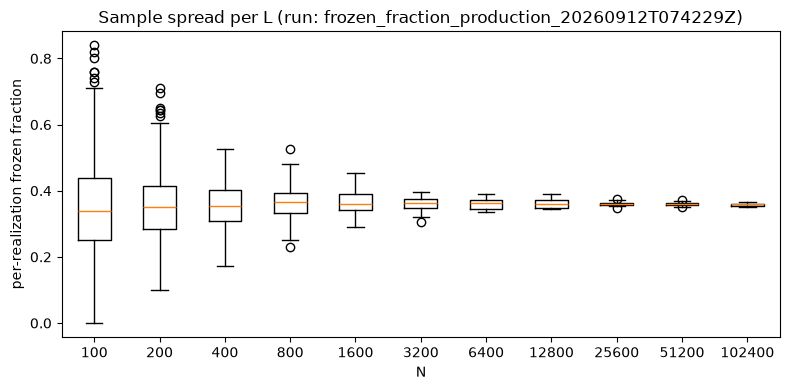

In [5]:
samples_by_L = {}
for row in summary:
    L = row['L']
    samples_by_L[L] = np.load(run_dir / f'L{L}_samples.npy')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [samples_by_L[L] for L in N],
    positions=range(len(N)),
    tick_labels=[str(L) for L in N],
)
ax.set_xlabel('N')
ax.set_ylabel('per-realization frozen fraction')
ax.set_title(f'Sample spread per L (run: {run_dir.name})')
fig.tight_layout()
plt.show()